## Modelo de Contenido Base

# ¿ Cómo funciona?

"Si te gustó esta canción → te recomiendo canciones que SUENAN parecido"

Cada canción = vector de 9 features de audio
    [danceability, energy, speechiness, acousticness,
     instrumentalness, liveness, valence, loudness_norm, tempo_norm]

Similitud entre dos canciones = cosine_similarity(vector_A, vector_B)
    -> valor entre 0 (nada parecidas) y 1 (idénticas)

# El resultado
Dado el historial de likes de un usuario, encontrar las N canciones más similares que aún no ha escuchado.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

sns.set_theme(style='whitegrid')

ITEMS_PATH = Path('/data/processed/items.csv')
if not ITEMS_PATH.exists():
	ITEMS_PATH = Path('../../data/processed/items.csv')
 
INTERACTIONS_PATH = Path('/data/processed/interactions.csv')
if not INTERACTIONS_PATH.exists():
	INTERACTIONS_PATH = Path('../../data/processed/interactions.csv')

# Features de audio que definen el "sonido" de una canción
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness_norm', 'tempo_norm'
]

# Carga de datos

In [20]:
items        = pd.read_csv(ITEMS_PATH)
items        = items.drop_duplicates(subset='ITEM_ID').copy()  # Evita índices duplicados en la recomendación
interactions = pd.read_csv(INTERACTIONS_PATH)

print(f'Canciones:      {len(items):,}')
print(f'Interacciones:  {len(interactions):,}')
items[['ITEM_ID', 'titulo', 'artista', 'genero'] + AUDIO_FEATURES].head()

Canciones:      89,741
Interacciones:  750,050


,ITEM_ID,titulo,artista,genero,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness_norm,tempo_norm
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,acoustic,0.676,0.4610,0.1430,0.0322,0.000001,0.3580,0.715,0.791392,0.361245
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,acoustic,0.420,0.1660,0.0763,0.9240,0.000006,0.1010,0.267,0.597377,0.318397
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0.438,0.3590,0.0557,0.2100,0.000000,0.1170,0.120,0.736123,0.313643
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,acoustic,0.266,0.0596,0.0363,0.9050,0.000071,0.1320,0.143,0.573701,0.746758
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,acoustic,0.618,0.4430,0.0526,0.4690,0.000000,0.0829,0.167,0.737103,0.492863


# Matriz de Features

In [23]:
# Indexar por ITEM_ID para búsquedas rápidas
items_indexed = items.set_index('ITEM_ID')

# Matriz de features: cada fila es una canción, cada columna es un feature de audio
feature_matrix = items_indexed[AUDIO_FEATURES].values

print(f'Shape de la matriz de features: {feature_matrix.shape}')
print(f' -> {feature_matrix.shape[0]:,} canciones × {feature_matrix.shape[1]} features de audio')

Shape de la matriz de features: (89741, 9)
 -> 89,741 canciones × 9 features de audio


# Función de Recomendación

In [24]:
# Mapa de ITEM_ID → índice de fila en la matriz
item_ids    = items_indexed.index.tolist()
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}


def recomendar_content_based(user_id: str, n: int = 10) -> pd.DataFrame:
    """
    Recomienda las N canciones más similares al perfil de audio del usuario.

    Estrategia:
    1. Obtener los likes del usuario
    2. Calcular el vector promedio de sus canciones likeadas (perfil de audio)
    3. Calcular la similitud de coseno entre ese perfil y todas las canciones
    4. Excluir las canciones que ya escuchó
    5. Retornar las N más similares
    """
    # 1. Historial del usuario (solo likes — señal positiva fuerte)
    historial = interactions[
        (interactions['USER_ID'] == user_id) &
        (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()

    if not historial:
        # Fallback: si no tiene likes, usar reproducciones
        historial = interactions[
            (interactions['USER_ID'] == user_id) &
            (interactions['EVENT_TYPE'] == 'play')
        ]['ITEM_ID'].tolist()

    if not historial:
        return pd.DataFrame(columns=['ITEM_ID', 'titulo', 'artista', 'genero', 'score_contenido'])

    # 2. Perfil de audio del usuario = promedio de sus likes
    indices_liked = [
        item_to_idx[item] for item in historial
        if item in item_to_idx
    ]
    perfil_usuario = feature_matrix[indices_liked].mean(axis=0).reshape(1, -1)

    # 3. Similitud de coseno contra todas las canciones
    scores = cosine_similarity(perfil_usuario, feature_matrix).flatten()

    # 4. Excluir canciones ya escuchadas (cualquier tipo de interacción)
    ya_escuchadas = set(
        interactions[interactions['USER_ID'] == user_id]['ITEM_ID'].tolist()
    )
    for item_id in ya_escuchadas:
        if item_id in item_to_idx:
            scores[item_to_idx[item_id]] = -1

    # 5. Top N
    top_indices = np.argsort(scores)[::-1][:n]
    top_items   = [item_ids[i] for i in top_indices]
    top_scores  = [scores[i] for i in top_indices]

    resultado = items_indexed.loc[top_items, ['titulo', 'artista', 'genero', 'popularidad']].copy()
    resultado['score_contenido'] = top_scores
    resultado = resultado.reset_index()

    return resultado


print('Función recomendar_content_based() definida')

Función recomendar_content_based() definida


# Prueba con un usuario real

In [25]:
# Elegir un usuario que tenga likes
usuario_prueba = interactions[
    interactions['EVENT_TYPE'] == 'like'
]['USER_ID'].value_counts().index[0]

print(f'Usuario de prueba: {usuario_prueba}')

# Ver sus likes
likes_usuario = interactions[
    (interactions['USER_ID'] == usuario_prueba) &
    (interactions['EVENT_TYPE'] == 'like')
]['ITEM_ID'].tolist()

print(f'Canciones likeadas: {len(likes_usuario)}')
print('\nSus likes:')
items_indexed.loc[
    [i for i in likes_usuario[:5] if i in items_indexed.index],
    ['titulo', 'artista', 'genero']
]

Usuario de prueba: user_4558
Canciones likeadas: 36

Sus likes:


,titulo,artista,genero
ITEM_ID,,,
3jwcudvYIksoAjU0x6gagd,Valerie,Steve Winwood,country
7tCL3GNUc04W2S7Cx1MzId,Serene Rain,Deep Sleep Rain Sounds,sleep
1wrSlSMgdb4STao5UKN5ML,Rough Day,Rain Sounds,sleep
76CSHuHKMJxmjmdrNBX2Z3,Victoria’s Secret,Jax,singer-songwriter
1kJvdhrr9MHOZ1e1PhTXTG,Drown,Prateek Kuhad,folk


In [26]:
# Obtener recomendaciones
recomendaciones_cb = recomendar_content_based(usuario_prueba, n=10)

print(f'Top 10 recomendaciones para {usuario_prueba}:')
recomendaciones_cb

Top 10 recomendaciones para user_4558:


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido
0,1JGW1e2tacnCgBPfRH0haY,Bird of Paradise,Snowy White,british,55,0.991320
1,0vINSp4xFZyj9NrQvoCC2d,Waiting For The Symphony,Night Moves,psych-rock,26,0.987543
2,7kM4yhMogdpiOZu0wL1UFy,Amerikha Expressa,BaianaSystem,afrobeat,28,0.986448
3,3v0krJCUzAT1K32SCnVO98,Highlight - Live,Faber,german,42,0.983981
4,0wY6Zaxswug2Wb9JZZ2HLv,DELETE SOUL,ALEX;TOKYO ROSE;THE AKUMA,club,39,0.983610
5,6ggA962ctXjQA5PZYUM3i6,Let it Be Known,The Growlers,garage,26,0.983470
6,3dC3qhF7T9fsfBpLVeZqcf,All for Money,Greensky Bluegrass,bluegrass,27,0.982383
7,5e0wGPEIDVmhPMYFkzzDkn,Golden Vibe,Beatnugget,study,29,0.982321
8,34DpOSd0pXWxUgFHA6HhJ0,Aurora,Zero 7;José González,trip-hop,41,0.981699
9,4yQCgQVUIRBUnLdmXtZ0bo,Winter Time,Steve Miller Band,psych-rock,51,0.981431


# Visualizar perfil de audio

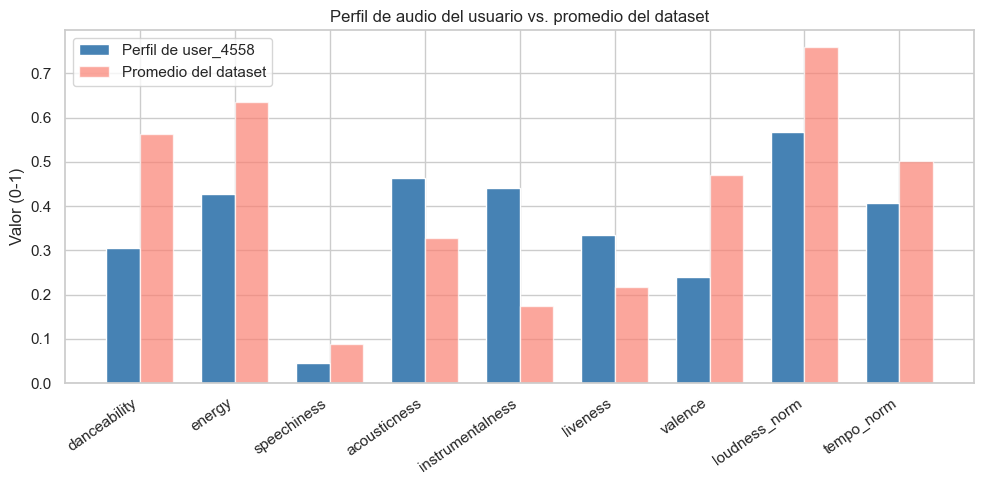

In [27]:
# Comparar perfil del usuario vs. perfil promedio del dataset
indices_liked = [
    item_to_idx[item] for item in likes_usuario
    if item in item_to_idx
]
perfil_usuario  = feature_matrix[indices_liked].mean(axis=0)
perfil_promedio = feature_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(AUDIO_FEATURES))
width = 0.35

ax.bar(x - width/2, perfil_usuario,  width, label=f'Perfil de {usuario_prueba}', color='steelblue')
ax.bar(x + width/2, perfil_promedio, width, label='Promedio del dataset',        color='salmon', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(AUDIO_FEATURES, rotation=35, ha='right')
ax.set_ylabel('Valor (0-1)')
ax.set_title('Perfil de audio del usuario vs. promedio del dataset')
ax.legend()
plt.tight_layout()
plt.show()

# Prueba con cualquier usuario

In [28]:
# Cambia el user_id aquí para probar con distintos usuarios
USER_ID_PRUEBA = 'user_15001'
N_RECOMENDACIONES = 10

resultado = recomendar_content_based(USER_ID_PRUEBA, n=N_RECOMENDACIONES)
print(f'Recomendaciones para {USER_ID_PRUEBA}:')
resultado

Recomendaciones para user_15001:


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido
0,6IxhlGtqmnnCIZX7j0nJtt,Shot You Down,Audio Bullys;Nancy Sinatra,breakbeat,45,0.996364
1,5RHcBbi9TvOKvU5TUpeFa9,The Same Parents,Enigma,new-age,42,0.995647
2,2O4O75liWpdFOt4B1jZSH7,Rollercoaster Baby,Oh Wonder,electro,1,0.995494
3,5E4jJga8yVK2CgXExQDnKi,Test & Recognise - Cassius Select Remix,Seekae;Cassius Select,idm,29,0.994571
4,5GGtoBwQtvoXRvfeKBToG1,Chama Por Mim,Pedro Gonçalves,disney,19,0.994548
5,1qW5H7li77nVfoAoXW0rGj,薄情歌,C AllStar,cantopop,48,0.994321
6,1qBUwGdIdB7R0aSwNzzdqu,Mais do que imaginei,Catedral,brazil,44,0.994203
7,6xF0hwsCAhQxENJg4JMGT7,Pergi Hilang Dan Lupakan - Demo Version,Remember of Today,punk,40,0.994040
8,1rg9XExYRDpEPn2cDqwz6A,Pelangi Baruku,Dhyo Haw,reggae,46,0.993927
9,3epxqmWkqp4HplaYp8NfMP,Innalekalil,Niranj Suresh,malay,47,0.993866


# Exportar Función

In [29]:
# Guardar los scores de content-based como referencia
# (útil para debuggear el modelo híbrido)
print('Variables disponibles para importar en 03_hybrid.ipynb:')
print('  - recomendar_content_based(user_id, n) -> DataFrame con score_contenido')
print('  - feature_matrix -> np.array (n_canciones × 9 features)')
print('  - item_to_idx -> dict ITEM_ID → índice')
print('  - item_ids -> lista ordenada de ITEM_IDs')

Variables disponibles para importar en 03_hybrid.ipynb:
  - recomendar_content_based(user_id, n) -> DataFrame con score_contenido
  - feature_matrix -> np.array (n_canciones × 9 features)
  - item_to_idx -> dict ITEM_ID → índice
  - item_ids -> lista ordenada de ITEM_IDs
